# Deep & Ensemble Learning

This notebook:
- Builds and tunes neural network models (MLP) using TensorFlow/Keras
- Experiments with architectures (depth, width) and regularization techniques (Dropout, BatchNorm, L2)
- Implements ensemble methods: **Stacking** (sklearn `StackingClassifier`) and **Blending** (manual holdout-based)

**Prerequisite:** Run `data_cleaning.ipynb` first to generate `Data/clean_train.csv`.

### Environment Setup
Required libraries:
- `pandas`, `numpy`, `matplotlib`
- `scikit-learn`
- `xgboost`
- `tensorflow >= 2.0`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Load Data & Prepare Features

In [ ]:
df = pd.read_csv("../Data/clean_train.csv")

drop_cols = ["Id", "Class", "EJ", "Alpha", "Beta", "Gamma", "Delta", "Epsilon"]
X = df.drop(columns=drop_cols)
y = df["Class"]

print("Feature shape:", X.shape)
print("Class distribution:\n", y.value_counts())

Feature shape: (617, 55)
Class distribution:
 Class
0    509
1    108
Name: count, dtype: int64


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print("Train shape:", X_train_scaled.shape)
print("Valid shape:", X_valid_scaled.shape)

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: n_neg / n_pos}
print(f"\nClass distribution — Class 0: {n_neg}, Class 1: {n_pos}")
print(f"Class weight for Class 1: {class_weight[1]:.2f}")

Train shape: (493, 55)
Valid shape: (124, 55)

Class distribution — Class 0: 407, Class 1: 86
Class weight for Class 1: 4.73


---
## Section 1: Neural Network Models

We use a Multi-Layer Perceptron (MLP) built with TensorFlow/Keras.

Key design choices:
- `class_weight` passed to `fit()` to compensate for class imbalance
- `EarlyStopping` with `restore_best_weights=True` to prevent overfitting on this small dataset
- `sigmoid` output + `binary_crossentropy` loss for binary classification

### 1.1 Baseline MLP

Two hidden layers (64 → 32 units), ReLU activations, no regularization.

In [5]:
def build_baseline(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_baseline = build_baseline(X_train_scaled.shape[1])
model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,697 (22.25 KB)

 Trainable params: 5,697 (22.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
es = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history_baseline = model_baseline.fit(
    X_train_scaled, y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=200,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[es],
    verbose=0
)

pred_baseline = (model_baseline.predict(X_valid_scaled) > 0.5).astype(int).flatten()
proba_baseline = model_baseline.predict(X_valid_scaled).flatten()

print("=== Baseline MLP ===")
print("Accuracy:", accuracy_score(y_valid, pred_baseline))
print("Log Loss:", log_loss(y_valid, proba_baseline))
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, pred_baseline))
print("\nClassification Report:")
print(classification_report(y_valid, pred_baseline))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== Baseline MLP ===
Accuracy: 0.9112903225806451
Log Loss: 0.15896736793083988

Confusion Matrix:
[[95  7]
 [ 4 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       102
           1       0.72      0.82      0.77        22

    accuracy                           0.91       124
   macro avg       0.84      0.87      0.86       124
weighted avg       0.92      0.91      0.91       124



### 1.2 Architecture Experiments

We vary the number of hidden layers (depth) and units per layer (width) to find the best architecture.
All other settings are held constant (ReLU, Adam lr=0.001, no regularization).

In [7]:
def build_mlp(input_dim, hidden_layers, units, lr=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(units, activation="relu"))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


architectures = [
    {"hidden_layers": 1, "units": 64},
    {"hidden_layers": 2, "units": 64},
    {"hidden_layers": 3, "units": 64},
    {"hidden_layers": 2, "units": 128},
    {"hidden_layers": 3, "units": 128},
    {"hidden_layers": 4, "units": 64},
]

arch_results = []
for arch in architectures:
    m = build_mlp(X_train_scaled.shape[1], arch["hidden_layers"], arch["units"])
    es_arch = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
    m.fit(
        X_train_scaled, y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=200, batch_size=32,
        class_weight=class_weight,
        callbacks=[es_arch], verbose=0
    )
    pred = (m.predict(X_valid_scaled) > 0.5).astype(int).flatten()
    proba = m.predict(X_valid_scaled).flatten()
    acc = accuracy_score(y_valid, pred)
    ll = log_loss(y_valid, proba)
    recall_1 = classification_report(y_valid, pred, output_dict=True)["1"]["recall"]
    arch_results.append({
        "hidden_layers": arch["hidden_layers"],
        "units_per_layer": arch["units"],
        "accuracy": round(acc, 4),
        "recall_class1": round(recall_1, 4),
        "log_loss": round(ll, 4)
    })

arch_df = pd.DataFrame(arch_results)
print("Architecture Comparison (sorted by log loss):")
display(arch_df.sort_values("log_loss"))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Architecture Comparison (sorted by log loss):


,hidden_layers,units_per_layer,accuracy,recall_class1,log_loss
0,1,64,0.9597,0.8636,0.0997
1,2,64,0.9597,0.9545,0.1528
3,2,128,0.9355,0.8182,0.1538
4,3,128,0.8952,0.6818,0.2283
2,3,64,0.9194,0.7727,0.2383
5,4,64,0.8871,0.5455,0.2764


### 1.3 Regularization Experiments

Three regularization techniques are tested on a 2-layer (128 → 64) architecture:
- **Dropout**: randomly zeros activations during training
- **Batch Normalization**: normalizes layer inputs to reduce internal covariate shift
- **L2 Weight Decay**: penalizes large weights in the loss function

In [ ]:
def build_with_dropout(input_dim, dropout_rate):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


dropout_rates = [0.2, 0.3, 0.4, 0.5]
dropout_results = []

for dr in dropout_rates:
    m = build_with_dropout(X_train_scaled.shape[1], dr)
    es_do = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
    m.fit(
        X_train_scaled, y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=200, batch_size=32,
        class_weight=class_weight,
        callbacks=[es_do], verbose=0
    )
    pred = (m.predict(X_valid_scaled) > 0.5).astype(int).flatten()
    proba = m.predict(X_valid_scaled).flatten()
    acc = accuracy_score(y_valid, pred)
    ll = log_loss(y_valid, proba)
    recall_1 = classification_report(y_valid, pred, output_dict=True)["1"]["recall"]
    dropout_results.append({
        "dropout_rate": dr,
        "accuracy": round(acc, 4),
        "recall_class1": round(recall_1, 4),
        "log_loss": round(ll, 4)
    })

print("Dropout Experiment Results:")
display(pd.DataFrame(dropout_results))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Dropout Experiment Results:


,dropout_rate,accuracy,recall_class1,log_loss
0,0.2,0.9355,0.9091,0.1595
1,0.3,0.9355,0.8182,0.0905
2,0.4,0.9194,0.8182,0.2008
3,0.5,0.9516,0.8636,0.1135


In [ ]:
def build_with_batchnorm(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


model_bn = build_with_batchnorm(X_train_scaled.shape[1])
es_bn = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
history_bn = model_bn.fit(
    X_train_scaled, y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=200, batch_size=32,
    class_weight=class_weight,
    callbacks=[es_bn], verbose=0
)

pred_bn = (model_bn.predict(X_valid_scaled) > 0.5).astype(int).flatten()
proba_bn = model_bn.predict(X_valid_scaled).flatten()

print("=== Batch Normalization Model ===")
print("Accuracy:", accuracy_score(y_valid, pred_bn))
print("Log Loss:", log_loss(y_valid, proba_bn))
print(classification_report(y_valid, pred_bn))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== Batch Normalization Model ===
Accuracy: 0.9274193548387096
Log Loss: 0.23517784816757706
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       102
           1       0.88      0.68      0.77        22

    accuracy                           0.93       124
   macro avg       0.91      0.83      0.86       124
weighted avg       0.93      0.93      0.92       124



In [10]:
# --- L2 Regularization ---
def build_with_l2(input_dim, l2_lambda):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


l2_values = [0.0001, 0.001, 0.01, 0.1]
l2_results = []

for l2 in l2_values:
    m = build_with_l2(X_train_scaled.shape[1], l2)
    es_l2 = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
    m.fit(
        X_train_scaled, y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=200, batch_size=32,
        class_weight=class_weight,
        callbacks=[es_l2], verbose=0
    )
    pred = (m.predict(X_valid_scaled) > 0.5).astype(int).flatten()
    proba = m.predict(X_valid_scaled).flatten()
    acc = accuracy_score(y_valid, pred)
    ll = log_loss(y_valid, proba)
    recall_1 = classification_report(y_valid, pred, output_dict=True)["1"]["recall"]
    l2_results.append({
        "l2_lambda": l2,
        "accuracy": round(acc, 4),
        "recall_class1": round(recall_1, 4),
        "log_loss": round(ll, 4)
    })

print("L2 Regularization Results:")
display(pd.DataFrame(l2_results))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
L2 Regularization Results:


,l2_lambda,accuracy,recall_class1,log_loss
0,0.0001,0.9194,0.8636,0.1974
1,0.0010,0.9355,0.7727,0.1436
2,0.0100,0.9435,0.8182,0.1339
3,0.1000,0.9032,0.9091,0.2327


### 1.4 Best Neural Network

The best architecture combines all three regularization techniques:
- **L2 weight decay** (`lambda=0.001`) on each Dense layer
- **Batch Normalization** after each Dense layer
- **Dropout** (rate=0.3) after BatchNorm
- `EarlyStopping` with longer patience (30) to allow sufficient training

In [11]:
def build_best_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


model_best = build_best_nn(X_train_scaled.shape[1])
es_best = EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)

history_best = model_best.fit(
    X_train_scaled, y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=300, batch_size=32,
    class_weight=class_weight,
    callbacks=[es_best],
    verbose=0
)

pred_best_nn = (model_best.predict(X_valid_scaled) > 0.5).astype(int).flatten()
proba_best_nn = model_best.predict(X_valid_scaled).flatten()

print("=== Best Neural Network (L2 + BatchNorm + Dropout) ===")
print("Accuracy:", accuracy_score(y_valid, pred_best_nn))
print("Log Loss:", log_loss(y_valid, proba_best_nn))
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, pred_best_nn))
print("\nClassification Report:")
print(classification_report(y_valid, pred_best_nn))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== Best Neural Network (L2 + BatchNorm + Dropout) ===
Accuracy: 0.9516129032258065
Log Loss: 0.1773493357766274

Confusion Matrix:
[[101   1]
 [  5  17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       102
           1       0.94      0.77      0.85        22

    accuracy                           0.95       124
   macro avg       0.95      0.88      0.91       124
weighted avg       0.95      0.95      0.95       124



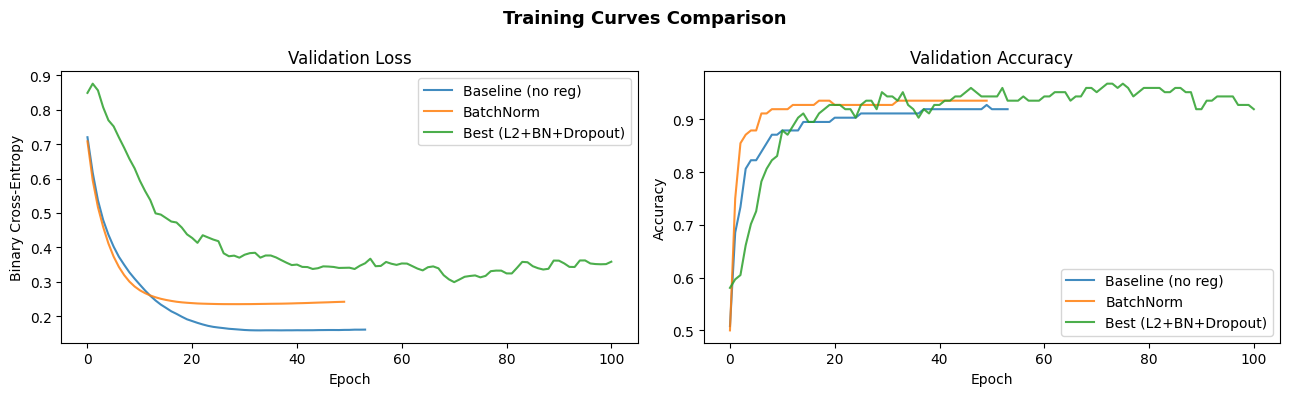

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_baseline.history["val_loss"], label="Baseline (no reg)", alpha=0.85)
axes[0].plot(history_bn.history["val_loss"], label="BatchNorm", alpha=0.85)
axes[0].plot(history_best.history["val_loss"], label="Best (L2+BN+Dropout)", alpha=0.85)
axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy")
axes[0].legend()

axes[1].plot(history_baseline.history["val_accuracy"], label="Baseline (no reg)", alpha=0.85)
axes[1].plot(history_bn.history["val_accuracy"], label="BatchNorm", alpha=0.85)
axes[1].plot(history_best.history["val_accuracy"], label="Best (L2+BN+Dropout)", alpha=0.85)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Training Curves Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 2: Ensemble Methods

We implement two ensemble strategies:

| Method | How it works |
|--------|-------------|
| **Stacking** | Base learners trained with 5-fold CV; their out-of-fold predictions become inputs to a meta-learner |
| **Blending** | Data split into base-train / holdout; base models trained on base-train, predict on holdout to build meta-features; meta-learner trained on those meta-features |

### 2.1 Stacking

Base learners:
- `LogisticRegression` (linear baseline)
- `RandomForestClassifier` (bagging)
- `GradientBoostingClassifier` (sequential boosting)
- `XGBClassifier` (with `scale_pos_weight` for imbalance)

Meta-learner: `LogisticRegression`

`sklearn.StackingClassifier` handles the cross-validation internally (`cv=5`).

In [13]:
base_learners = [
    ("logreg", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ("rf",     RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
    ("gbm",    GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ("xgb",    XGBClassifier(
                   n_estimators=100, scale_pos_weight=n_neg/n_pos,
                   random_state=42, eval_metric="logloss"
               )),
]

stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    passthrough=False,
    n_jobs=-1
)

stack_clf.fit(X_train_scaled, y_train)

pred_stack = stack_clf.predict(X_valid_scaled)
proba_stack = stack_clf.predict_proba(X_valid_scaled)[:, 1]

print("=== Stacking Ensemble ===")
print("Accuracy:", accuracy_score(y_valid, pred_stack))
print("Log Loss:", log_loss(y_valid, proba_stack))
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, pred_stack))
print("\nClassification Report:")
print(classification_report(y_valid, pred_stack))

=== Stacking Ensemble ===
Accuracy: 0.9354838709677419
Log Loss: 0.18144984797156913

Confusion Matrix:
[[100   2]
 [  6  16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       102
           1       0.89      0.73      0.80        22

    accuracy                           0.94       124
   macro avg       0.92      0.85      0.88       124
weighted avg       0.93      0.94      0.93       124



### 2.2 Blending

Unlike stacking (which uses full CV), blending uses a single holdout split:

1. Split `X_train` → `X_blend_train` (70%) + `X_blend_holdout` (30%)
2. Train base models (LogReg, RF, GBM, XGB, NN) on `X_blend_train`
3. Predict probabilities on `X_blend_holdout` → build meta-features
4. Train `LogisticRegression` meta-learner on those meta-features
5. Evaluate: base models predict on `X_valid`, feed to meta-learner → final prediction

In [ ]:
#Blending split
X_blend_train, X_blend_holdout, y_blend_train, y_blend_holdout = train_test_split(
    X_train_scaled, y_train, test_size=0.3, random_state=42, stratify=y_train
)
print("Blend train:", X_blend_train.shape, "| Blend holdout:", X_blend_holdout.shape)

# Train sklearn base models on blend_train
sklearn_base_models = {
    "logreg": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "rf":     RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "gbm":    GradientBoostingClassifier(n_estimators=100, random_state=42),
    "xgb":    XGBClassifier(
                  n_estimators=100,
                  scale_pos_weight=(y_blend_train == 0).sum() / (y_blend_train == 1).sum(),
                  random_state=42, eval_metric="logloss"
              ),
}

for name, m in sklearn_base_models.items():
    m.fit(X_blend_train, y_blend_train)
    print(f"Trained {name}")

# Train Keras NN on blend_train
n_neg_b = (y_blend_train == 0).sum()
n_pos_b = (y_blend_train == 1).sum()
cw_blend = {0: 1.0, 1: n_neg_b / n_pos_b}

blend_nn = build_best_nn(X_blend_train.shape[1])
es_blend = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
blend_nn.fit(
    X_blend_train, y_blend_train,
    validation_split=0.1,
    epochs=200, batch_size=16,
    class_weight=cw_blend,
    callbacks=[es_blend], verbose=0
)
print("Trained nn")

Blend train: (345, 55) | Blend holdout: (148, 55)
Trained logreg
Trained rf
Trained gbm
Trained xgb
Trained nn


In [ ]:
# Build meta-features from holdout predictions
meta_holdout = np.column_stack(
    [m.predict_proba(X_blend_holdout)[:, 1] for m in sklearn_base_models.values()]
    + [blend_nn.predict(X_blend_holdout).flatten()]
)
print("Meta-feature matrix (holdout):", meta_holdout.shape)
print("Columns: logreg, rf, gbm, xgb, nn")

# Train meta-learner on holdout meta-features
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(meta_holdout, y_blend_holdout)

# Build meta-features for validation set
meta_valid = np.column_stack(
    [m.predict_proba(X_valid_scaled)[:, 1] for m in sklearn_base_models.values()]
    + [blend_nn.predict(X_valid_scaled).flatten()]
)

pred_blend = meta_model.predict(meta_valid)
proba_blend = meta_model.predict_proba(meta_valid)[:, 1]

print("\n=== Blending Ensemble ===")
print("Accuracy:", accuracy_score(y_valid, pred_blend))
print("Log Loss:", log_loss(y_valid, proba_blend))
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, pred_blend))
print("\nClassification Report:")
print(classification_report(y_valid, pred_blend))

# Show meta-learner coefficients to understand base model contributions
coef_df = pd.DataFrame({
    "model": list(sklearn_base_models.keys()) + ["nn"],
    "meta_weight": meta_model.coef_[0]
})
print("\nMeta-learner weights:")
display(coef_df.sort_values("meta_weight", ascending=False))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Meta-feature matrix (holdout): (148, 5)
Columns: logreg, rf, gbm, xgb, nn
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

=== Blending Ensemble ===
Accuracy: 0.9193548387096774
Log Loss: 0.20051995432667366

Confusion Matrix:
[[100   2]
 [  8  14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       102
           1       0.88      0.64      0.74        22

    accuracy                           0.92       124
   macro avg       0.90      0.81      0.84       124
weighted avg       0.92      0.92      0.91       124


Meta-learner weights:


,model,meta_weight
2,gbm,2.054113
3,xgb,1.372924
1,rf,1.204425
4,nn,1.163382
0,logreg,0.996361


---
## Final Model Comparison

Comparing all models developed in this notebook against the XGBoost weighted baseline from `boosting_xgboost.ipynb`.

In [16]:
def get_metrics(y_true, y_pred, y_proba):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "recall_class1": round(report["1"]["recall"], 4),
        "f1_class1": round(report["1"]["f1-score"], 4),
        "log_loss": round(log_loss(y_true, y_proba), 4)
    }


results = {
    "XGBoost Weighted (baseline)": {"accuracy": 0.9274, "recall_class1": 0.73, "f1_class1": 0.78, "log_loss": 0.2037},
    "NN Baseline": get_metrics(y_valid, pred_baseline, proba_baseline),
    "NN Best (L2+BN+Dropout)": get_metrics(y_valid, pred_best_nn, proba_best_nn),
    "Stacking": get_metrics(y_valid, pred_stack, proba_stack),
    "Blending": get_metrics(y_valid, pred_blend, proba_blend),
}

results_df = pd.DataFrame(results).T
print("Final Model Comparison (sorted by log loss):")
display(results_df.sort_values("log_loss"))

Final Model Comparison (sorted by log loss):


,accuracy,recall_class1,f1_class1,log_loss
NN Baseline,0.9113,0.8182,0.7660,0.1590
NN Best (L2+BN+Dropout),0.9516,0.7727,0.8500,0.1773
Stacking,0.9355,0.7273,0.8000,0.1814
Blending,0.9194,0.6364,0.7368,0.2005
XGBoost Weighted (baseline),0.9274,0.7300,0.7800,0.2037


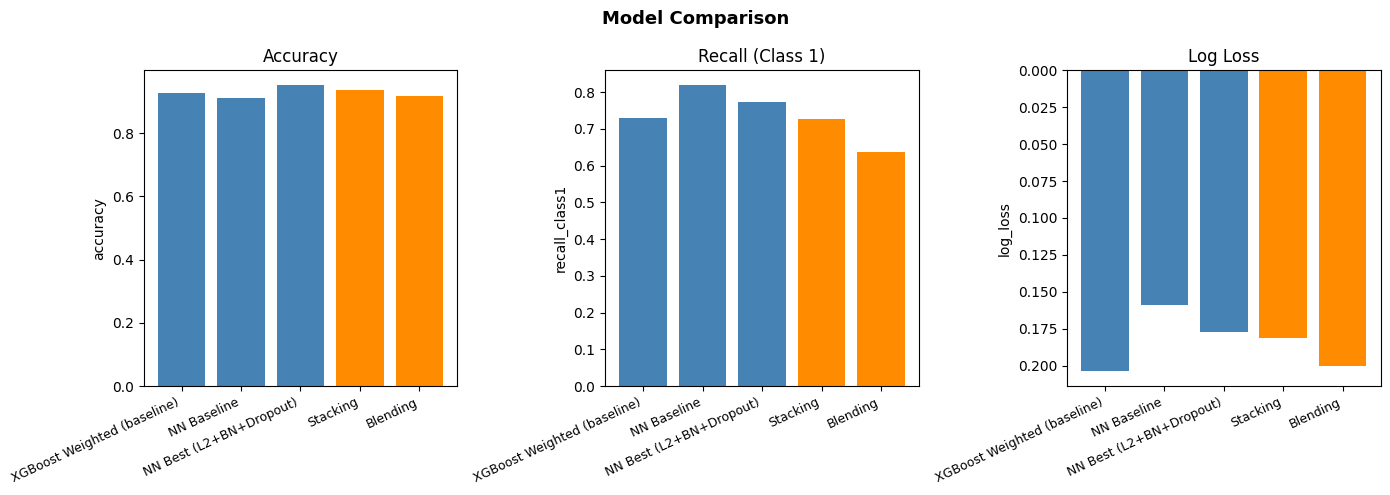

In [17]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ["accuracy", "recall_class1", "log_loss"]
titles = ["Accuracy", "Recall (Class 1)", "Log Loss"]

for ax, metric, title in zip(axes, metrics, titles):
    values = results_df[metric].astype(float)
    colors = ["steelblue" if i < len(values) - 2 else "darkorange" for i in range(len(values))]
    ax.bar(values.index, values.values, color=colors)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xticklabels(values.index, rotation=25, ha="right", fontsize=9)
    if metric == "log_loss":
        ax.invert_yaxis()

plt.suptitle("Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()